# Plot from dicts

## Bring Plots from plotting_df_77_97_mrn

### Bring ***imports*** & ***det functions from*** plotting_df_77_97_mrn

#### ***imports*** 

In [2]:
# Imports required for Loading, sorting .csx files to create specific data sets ie mrn inbody readings. 
%run ./sys_funcs.py              # loads all the def functions in sys_funcs.py into memory
#import sys_funcs                 # gives access to these def function digitalform that are in memory
from pathlib import Path
import csv
import pandas as pd
import numpy as np
#import tkinter as tk
import pickle
from pathlib import Path
import csv
import os
import sys
from datetime import datetime
from datetime import time
from sys_funcs import read_csv_to_array
from sys_funcs import clean_wsl_path
from sys_funcs import array_to_dt_row_dict
from sys_funcs import make_blnk_update_row_dict
from sys_funcs import transpose_csv_to_col_dict
#from sys_funcs import update_values_with_config, get_update_result
from sys_funcs import transfer_updates
from sys_funcs import get_dtv_range
from sys_funcs import universal_import
from sys_funcs import parse_inbody_timestamp
from sys_funcs import build_lut
from sys_funcs import extract_a_column_as_df
from sys_funcs import extract_multicolumns_as_df
from sys_funcs import validate_and_sort_timestamps
from sys_funcs import extract_and_filter_by_time_window
from sys_funcs import read_file_dual_path
from sys_funcs import write_file_dual_path
from sys_funcs import asc_to_csv_cnv
from collections.abc import Mapping
import re
import pandas as pd
from pathlib import Path
import pickle
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import unicodedata
import re
import pandas as pd
from pathlib import Path
import pickle
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import unicodedata
import re
#from sys_funcs import 

#### ***det functions***

In [19]:
def get_ctrl_row(unq_row_nm, ctrl_dct):                # FINDS THE ROW THAT MATCH PLT_LST_NM AND RETURN THAT ROW OF KEY VALUES
    target = clean_colname(unq_row_nm)                # Makes sure target is clean so it will match one of the cleaned keys

    for row_key, row in ctrl_dct.items():             # cleans all of key0  until it finds a clean one.
        stored = clean_colname(row.get(0))

        if stored == target:
            return [row[k] for k in sorted(row.keys()) if k != 0]

    raise KeyError(f"Control '{unq_row_nm}' not found after cleaning.")


In [4]:
# def read_from_pkl(name):   # name is a string: read_from_pkl("ib_dct")import pickle

import inspect

def read_from_pkl(name):   # name is a string: read_from_pkl("ib_dct")
    filename = f"{name}.pkl"

    # Load the object from pickle
    with open(filename, "rb") as f:
        loaded_obj = pickle.load(f)

    # Assign into caller's local scope
    frame = inspect.currentframe().f_back
    frame.f_locals[name] = loaded_obj

    print(f"{name} updated from {filename}")
    return None



In [5]:
#  def write_to_pkl(name):   # name is a string: write_to_pkl("ib_dct")
import pickle
import inspect

def write_to_pkl(name):   # name is a string: write_to_pkl("ib_dct")
    # Access caller frame
    frame = inspect.currentframe().f_back

    # Pull the object from caller's local variables
    if name not in frame.f_locals:
        raise NameError(f"Variable '{name}' does not exist in caller scope")

    obj = frame.f_locals[name]

    # Write to pickle
    filename = f"{name}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(obj, f)

    print(f"{name} written to {filename}")
    return None


In [18]:
# def plot_multi_dual(df, *cols, save_pdf=True):
def plot_multi_dual(df, *cols, save_pdf=True):
    # this uses a "df" and a "plotlist" and plots the graphs on screen, and optionally plots them into a PDF file for printing
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd
    import os, re

    # Work on a safe copy
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Color cycle (extend if needed)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(12, 5))

    # First column on left axis
    ax.plot(
        df["timestamp"],
        df[cols[0]],
        marker="o",
        color=color_cycle[0],
        label=cols[0]
    )
    ax.set_ylabel(cols[0], color=color_cycle[0])
    ax.tick_params(axis="y", labelcolor=color_cycle[0])
    axes = [ax]

    # Additional columns on stacked right axes
    for i, col in enumerate(cols[1:], start=1):
        ax_new = ax.twinx()
        ax_new.spines.right.set_position(("axes", 1 + 0.1 * (i - 1)))

        color = color_cycle[i % len(color_cycle)]
        ax_new.plot(
            df["timestamp"],
            df[col],
            marker="o",
            color=color,
            label=col
        )
        ax_new.set_ylabel(col, color=color)
        ax_new.tick_params(axis="y", labelcolor=color)

        axes.append(ax_new)

    # Minor ticks every day
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Major ticks weekly (Mondays)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Rotate major tick labels for readability
    for label in ax.get_xticklabels(which="major"):
        label.set_rotation(45)
        label.set_ha("right")

    # Grid on major ticks
    ax.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.7)

    plt.xticks(rotation=45)
    plt.title(" / ".join(cols) + " over time")
    plt.tight_layout()

    # === SAVE BLOCK (PDF, WSL-safe, sanitized filename) ===
    if save_pdf:
        save_dir = "/mnt/c/Users/bhuns/OneDrive/___ib_plots"
        os.makedirs(save_dir, exist_ok=True)

        # Build clean filename
        chart_title = " vs ".join(cols)
        chart_title = chart_title.replace("/", "_")
        chart_title = re.sub(r'[^A-Za-z0-9_-]+', '_', chart_title)

        # Add timestamp
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        chart_title = f"{timestamp}_{chart_title}"

        pdf_path = f"{save_dir}/{chart_title}.pdf"

        fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

    plt.show()


#### *Import ***dat_dct*** from all sources

In [13]:
#verify df_77_97_mrn #ok

#### Create ***plt_lst***   ......................   add to ***plt_lst_dct***

In [25]:
# Plots by subject  
plt_lst = ["smm_(skeletal_muscle_mass)","vfa_(visceral_fat_area)"]
plt_lst_nm = "smm_vfa"
plt_lst_dct = {
    key0)[plt_lst_nm] = plt_lst

NameError: name 'plt_lst_dct' is not defined

#### Select ***plt_lst***   from ***plt_lst_dct***   ............   key 0:plt_lst_nm

In [22]:
plt_lst = get_ctrl_row(plt_lst_nm, plt_lst_dct)

NameError: name 'plt_lst_dct' is not defined

#### Create ***plt_lst_dct***            key 0:plt_lst_nm

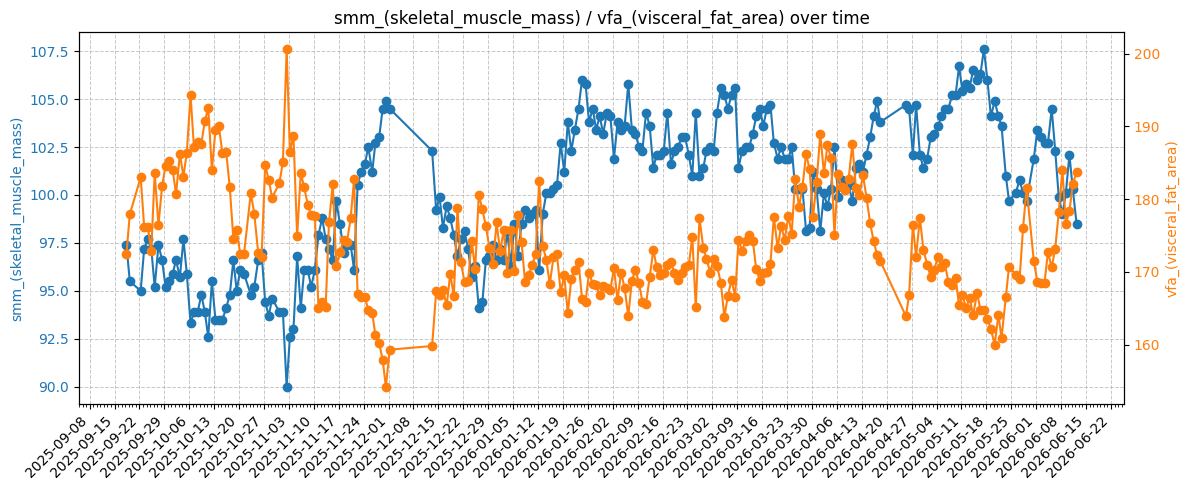

In [ ]:
plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=False) 
# plot_multi_dual(df_77_97_mrn, *plt_lst,save_pdf=True)  

## Import Dcts

## Plot from Dcts